# N3 — LiDAR 3D Object Detection & Tracking

This notebook builds a complete **3D object detection and tracking pipeline** from raw LiDAR point clouds — no pre-trained detectors, just geometry and clustering.

**What you will learn:**
1. **Ground plane removal** using surface normal estimation
2. **Euclidean clustering** (DBSCAN) to segment individual obstacles
3. **3D bounding box** extraction from point clusters
4. **Multi-object tracking** with the Kalman filter from N2, extended to 3D
5. **Future state prediction** — where will each tracked object be in the next few timesteps?

**Pipeline overview:**

```
 Raw LiDAR ──► ROI Crop ──► Ground Removal ──► Clustering ──► 3D Bboxes
  (120k pts)   (~30k pts)   (normal filter)     (DBSCAN)     (per object)
                                                                  │
                                                                  ▼
  Tracking Video ◄── Kalman Predict/Update ◄── Hungarian Assignment
  (BEV + Camera)     (3D constant velocity)     (distance cost)
```

In [59]:
%pip install numpy matplotlib pykitti scipy scikit-learn imageio[ffmpeg] transformers torch torchvision --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import DBSCAN
import pykitti
import imageio
import os
from io import BytesIO

np.random.seed(42)

data = pykitti.raw("kitti_data", "2011_09_26", "0005")
num_frames = len(data.timestamps)

try:
    dt = (data.timestamps[1] - data.timestamps[0]).total_seconds()
except Exception:
    dt = 0.1

# Projection: Velodyne → Camera 2 image
T_cam_velo = np.array(data.calib.T_cam0_velo)  # (4,4) includes R_rect
P2 = np.array(data.calib.P_rect_20)             # (3,4)
M_proj = P2 @ T_cam_velo                         # (3,4)

velo_0 = data.get_velo(0)
print(f"KITTI drive 0005: {num_frames} frames at {1/dt:.0f} Hz (dt = {dt:.3f} s)")
print(f"Frame 0: {velo_0.shape[0]:,} points  [X, Y, Z, reflectance]")
print(f"X range: [{velo_0[:,0].min():.1f}, {velo_0[:,0].max():.1f}] m  (forward / back)")
print(f"Y range: [{velo_0[:,1].min():.1f}, {velo_0[:,1].max():.1f}] m  (left / right)")
print(f"Z range: [{velo_0[:,2].min():.1f}, {velo_0[:,2].max():.1f}] m  (up / down)")

KITTI drive 0005: 154 frames at 9 Hz (dt = 0.110 s)
Frame 0: 123,397 points  [X, Y, Z, reflectance]
X range: [-64.3, 68.5] m  (forward / back)
Y range: [-79.8, 77.7] m  (left / right)
Z range: [-7.0, 2.9] m  (up / down)


## 1. Bird's-Eye View of Raw LiDAR

The Velodyne HDL-64E returns ~120,000 points per scan in the sensor frame: **X** forward, **Y** left, **Z** up. We crop to a forward-facing region of interest and plot a bird's-eye view — looking straight down from above.

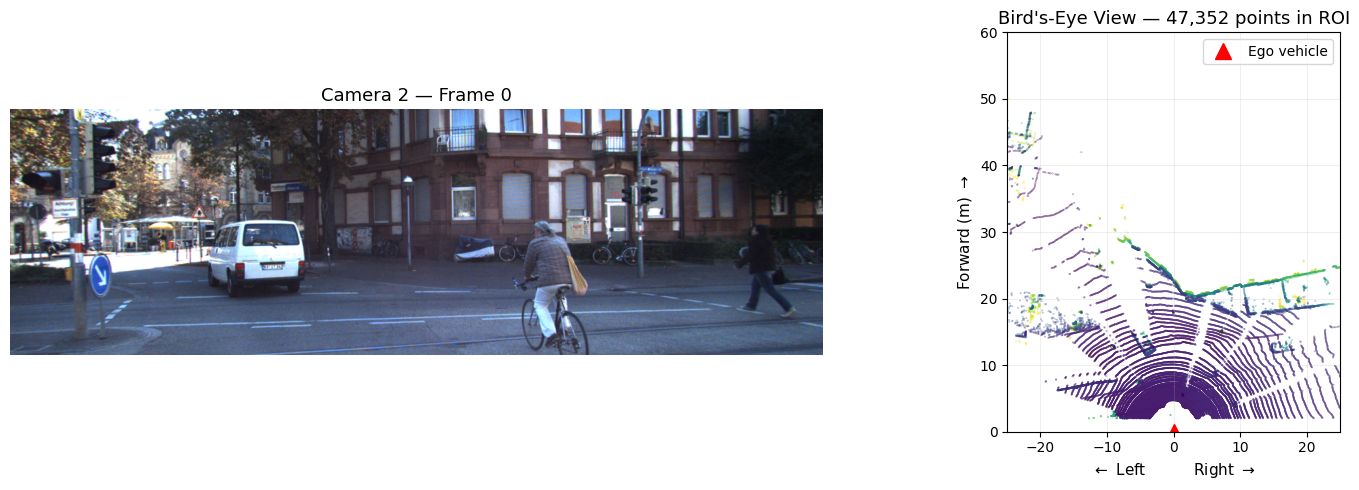

ROI crop: 47,352 / 123,397 points (38%)


In [61]:
ROI = {'x': (2, 60), 'y': (-25, 25), 'z': (-2.5, 1.5)}

def crop_roi(points, roi=ROI):
    m = ((points[:, 0] >= roi['x'][0]) & (points[:, 0] <= roi['x'][1]) &
         (points[:, 1] >= roi['y'][0]) & (points[:, 1] <= roi['y'][1]) &
         (points[:, 2] >= roi['z'][0]) & (points[:, 2] <= roi['z'][1]))
    return points[m]

pts_roi = crop_roi(velo_0[:, :3])

fig, (ax_cam, ax_bev) = plt.subplots(1, 2, figsize=(16, 5))

ax_cam.imshow(np.array(data.get_cam2(0)))
ax_cam.set_title("Camera 2 — Frame 0", fontsize=13)
ax_cam.axis('off')

ax_bev.scatter(-pts_roi[:, 1], pts_roi[:, 0], s=0.1, c=pts_roi[:, 2],
               cmap='viridis', alpha=0.5, vmin=-2, vmax=1)
ax_bev.set_xlim(-25, 25)
ax_bev.set_ylim(0, 60)
ax_bev.set_xlabel(r'$\leftarrow$ Left          Right $\rightarrow$', fontsize=11)
ax_bev.set_ylabel(r'Forward (m) $\rightarrow$', fontsize=11)
ax_bev.set_title(f"Bird's-Eye View — {len(pts_roi):,} points in ROI", fontsize=13)
ax_bev.set_aspect('equal')
ax_bev.plot(0, 0, 'r^', markersize=12, label='Ego vehicle')
ax_bev.legend(fontsize=10)
ax_bev.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"ROI crop: {len(pts_roi):,} / {velo_0.shape[0]:,} points "
      f"({100 * len(pts_roi) / velo_0.shape[0]:.0f}%)")

## 2. Ground Plane Removal via Surface Normal Estimation

To detect obstacles we first remove the ground. The approach:

1. **Height pre-filter** — points near ground level ($z \in [-2.5, -0.8]$ m in the Velodyne frame) are ground candidates
2. **Voxel downsample** — reduce candidates to one point per 0.2 m voxel for speed
3. **Estimate surface normals** — for each point's local neighborhood, the normal is the eigenvector of the **smallest eigenvalue** of the local covariance matrix:

$$\mathbf{n} = \text{eigvec}_{\min}\left(\frac{1}{k}\sum_{i=1}^{k}(\mathbf{p}_i - \bar{\mathbf{p}})(\mathbf{p}_i - \bar{\mathbf{p}})^\top\right)$$

4. **Filter by verticality** — ground normals point nearly straight up: $|\mathbf{n}_z| > 0.85$

In [62]:
def estimate_normals(points, k=20):
    tree = cKDTree(points)
    _, idx = tree.query(points, k=min(k, len(points)))
    neighborhoods = points[idx]                                   # (N, k, 3)
    centered = neighborhoods - neighborhoods.mean(axis=1, keepdims=True)
    covs = np.einsum('nki,nkj->nij', centered, centered) / (k - 1)  # (N, 3, 3)
    covs += np.eye(3)[None] * 1e-6                                # regularize
    eigenvalues, eigenvectors = np.linalg.eigh(covs)
    normals = eigenvectors[:, :, 0]                               # smallest eigenvec
    normals[normals[:, 2] < 0] *= -1                              # orient upward
    return normals


def remove_ground(points, k=20, z_range=(-2.5, -0.8),
                  normal_thresh=0.85, voxel_size=0.2):
    cand_mask = (points[:, 2] >= z_range[0]) & (points[:, 2] <= z_range[1])
    if cand_mask.sum() < k:
        return np.zeros(len(points), dtype=bool)

    cand_pts = points[cand_mask]

    # Voxel downsample for fast normal estimation
    vox_keys = np.floor(cand_pts / voxel_size).astype(np.int64)
    _, uniq_idx, inverse = np.unique(vox_keys, axis=0,
                                     return_index=True, return_inverse=True)
    downsampled = cand_pts[uniq_idx]

    k_use = min(k, len(downsampled) - 1)
    if k_use < 4:
        return np.zeros(len(points), dtype=bool)

    normals = estimate_normals(downsampled, k=k_use)
    is_ground_voxel = np.abs(normals[:, 2]) > normal_thresh
    is_ground_cand = is_ground_voxel[inverse]

    ground_mask = np.zeros(len(points), dtype=bool)
    ground_mask[np.where(cand_mask)[0][is_ground_cand]] = True
    return ground_mask

print("Functions defined: estimate_normals(), remove_ground()")

Functions defined: estimate_normals(), remove_ground()


### Visualizing Surface Normals

Before we apply the ground filter, let's build intuition for what surface normals look like on real LiDAR data.

Every point's **surface normal** is estimated from its local neighborhood using PCA — the normal is the direction of *least variance* among nearby points. For a flat road surface, normals point nearly straight up ($|n_z| \approx 1$). For vertical surfaces like cars, walls, or poles, normals point sideways ($|n_z| \approx 0$).

The plots below show normals as arrows on a small patch of the scene, colored by **verticality** $|n_z|$:
- **Green** → vertical normal (ground-like)
- **Red** → horizontal normal (obstacle-like)
- The dashed line at $|n_z| = 0.85$ is our classification threshold

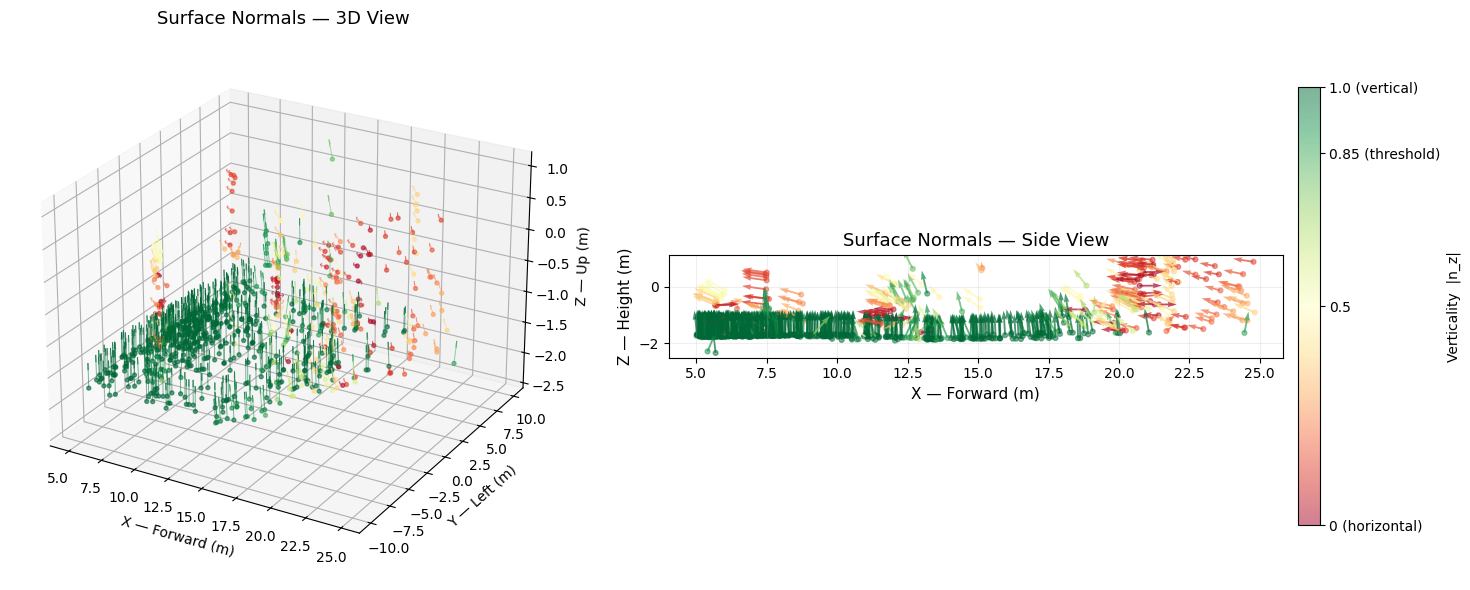

Patch: 800 points  |  Vertical (|n_z| > 0.85): 552 (69%)  |  Non-vertical: 248
Green arrows = ground (pointing up)  |  Red arrows = obstacles (pointing sideways)


In [63]:
# Compute normals on a small region for visualization
# Take a patch in front of the vehicle that includes both road and obstacles
patch_mask = ((pts_roi[:, 0] > 5) & (pts_roi[:, 0] < 25) &
              (pts_roi[:, 1] > -10) & (pts_roi[:, 1] < 10))
patch_pts = pts_roi[patch_mask]

# Subsample for clarity
np.random.seed(42)
n_vis = min(800, len(patch_pts))
vis_idx = np.random.choice(len(patch_pts), n_vis, replace=False)
vis_pts = patch_pts[vis_idx]

normals_vis = estimate_normals(vis_pts, k=15)
verticality = np.abs(normals_vis[:, 2])

fig = plt.figure(figsize=(16, 6))

# Left: 3D perspective with normal arrows
ax3d = fig.add_subplot(121, projection='3d')
sc = ax3d.scatter(vis_pts[:, 0], vis_pts[:, 1], vis_pts[:, 2],
                  c=verticality, cmap='RdYlGn', s=8, alpha=0.6, vmin=0, vmax=1)
arrow_len = 0.4
ax3d.quiver(vis_pts[:, 0], vis_pts[:, 1], vis_pts[:, 2],
            normals_vis[:, 0] * arrow_len,
            normals_vis[:, 1] * arrow_len,
            normals_vis[:, 2] * arrow_len,
            color=plt.cm.RdYlGn(verticality), alpha=0.5, linewidth=0.7,
            arrow_length_ratio=0.3)
ax3d.set_xlabel('X — Forward (m)')
ax3d.set_ylabel('Y — Left (m)')
ax3d.set_zlabel('Z — Up (m)')
ax3d.set_title('Surface Normals — 3D View', fontsize=13)
ax3d.view_init(elev=25, azim=-60)

# Right: side view (X vs Z) — clearest way to see ground vs obstacle normals
ax_side = fig.add_subplot(122)
sc2 = ax_side.scatter(vis_pts[:, 0], vis_pts[:, 2], c=verticality,
                      cmap='RdYlGn', s=12, alpha=0.5, vmin=0, vmax=1)
ax_side.quiver(vis_pts[:, 0], vis_pts[:, 2],
               normals_vis[:, 0], normals_vis[:, 2],
               verticality, cmap='RdYlGn', clim=(0, 1),
               scale=25, width=0.003, alpha=0.7)
ax_side.set_xlabel('X — Forward (m)', fontsize=11)
ax_side.set_ylabel('Z — Height (m)', fontsize=11)
ax_side.set_title('Surface Normals — Side View', fontsize=13)
ax_side.set_aspect('equal')
ax_side.grid(True, alpha=0.2)

cbar = fig.colorbar(sc2, ax=ax_side, shrink=0.8, pad=0.02)
cbar.set_label('Verticality  |n_z|', fontsize=10)
cbar.ax.set_yticks([0, 0.5, 0.85, 1.0])
cbar.ax.set_yticklabels(['0 (horizontal)', '0.5', '0.85 (threshold)', '1.0 (vertical)'])

plt.tight_layout()
plt.show()

n_vert = (verticality > 0.85).sum()
print(f"Patch: {n_vis} points  |  Vertical (|n_z| > 0.85): {n_vert} "
      f"({100*n_vert/n_vis:.0f}%)  |  Non-vertical: {n_vis - n_vert}")
print("Green arrows = ground (pointing up)  |  Red arrows = obstacles (pointing sideways)")

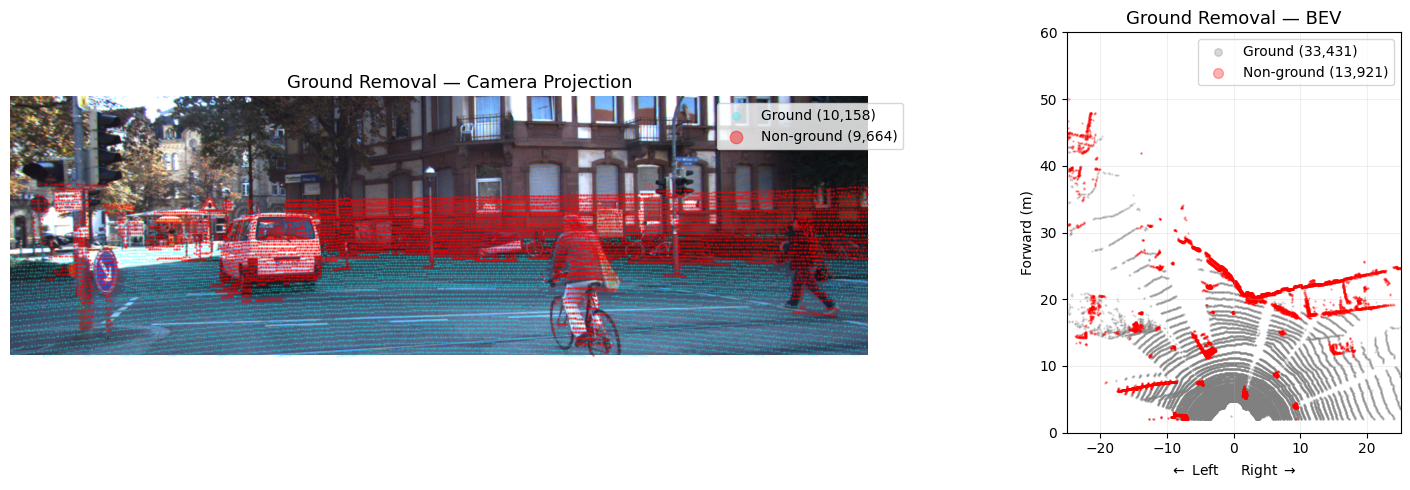

Ground: 33,431 pts  |  Non-ground: 13,921 pts


In [64]:
# --- Apply ground removal and project onto camera image ---
ground_mask = remove_ground(pts_roi)
ground = pts_roi[ground_mask]
non_ground = pts_roi[~ground_mask]

def project_points(pts_3d, M, img_shape):
    hom = np.hstack([pts_3d, np.ones((len(pts_3d), 1))])
    proj = (M @ hom.T).T
    depth = proj[:, 2]
    valid = depth > 0.5
    pts_2d = np.zeros((len(pts_3d), 2))
    if valid.any():
        pts_2d[valid] = proj[valid, :2] / proj[valid, 2:3]
    h, w = img_shape[:2]
    in_img = valid & (pts_2d[:, 0] >= 0) & (pts_2d[:, 0] < w) & \
             (pts_2d[:, 1] >= 0) & (pts_2d[:, 1] < h)
    return pts_2d, in_img, depth

img_0 = np.array(data.get_cam2(0))

# Project ground and non-ground points to camera
uv_g, vis_g, d_g = project_points(ground, M_proj, img_0.shape)
uv_ng, vis_ng, d_ng = project_points(non_ground, M_proj, img_0.shape)

fig, (ax_cam, ax_bev) = plt.subplots(1, 2, figsize=(16, 5),
                                      gridspec_kw={'width_ratios': [1.3, 1]})

# Left: camera image with projected ground / non-ground overlay
ax_cam.imshow(img_0)
ax_cam.scatter(uv_g[vis_g, 0], uv_g[vis_g, 1], s=0.3, c='cyan', alpha=0.25,
               label=f'Ground ({vis_g.sum():,})')
ax_cam.scatter(uv_ng[vis_ng, 0], uv_ng[vis_ng, 1], s=0.8, c='red', alpha=0.4,
               label=f'Non-ground ({vis_ng.sum():,})')
ax_cam.legend(fontsize=10, loc='upper right', markerscale=10)
ax_cam.set_title('Ground Removal — Camera Projection', fontsize=13)
ax_cam.axis('off')

# Right: BEV
ax_bev.scatter(-ground[:, 1], ground[:, 0], s=0.3, c='gray', alpha=0.3,
               label=f'Ground ({len(ground):,})')
ax_bev.scatter(-non_ground[:, 1], non_ground[:, 0], s=0.5, c='red', alpha=0.3,
               label=f'Non-ground ({len(non_ground):,})')
ax_bev.set_xlim(-25, 25); ax_bev.set_ylim(0, 60)
ax_bev.set_aspect('equal')
ax_bev.legend(fontsize=10, markerscale=10)
ax_bev.set_title('Ground Removal — BEV', fontsize=13)
ax_bev.set_xlabel(r'$\leftarrow$ Left     Right $\rightarrow$')
ax_bev.set_ylabel('Forward (m)')
ax_bev.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Ground: {len(ground):,} pts  |  Non-ground: {len(non_ground):,} pts")

## 3. Euclidean Clustering & 3D Bounding Boxes

Non-ground points are grouped into clusters using **DBSCAN** — a density-based algorithm that is equivalent to Euclidean clustering:

- Two points are **neighbors** if their distance $< \varepsilon$
- A cluster needs at least `min_samples` connected neighbors
- Points that don't belong to any cluster are labeled **noise** (−1)

After clustering, we fit **axis-aligned 3D bounding boxes** and filter by physical dimensions to keep vehicle-sized objects (height 0.3–3.5 m, length 0.5–15 m).

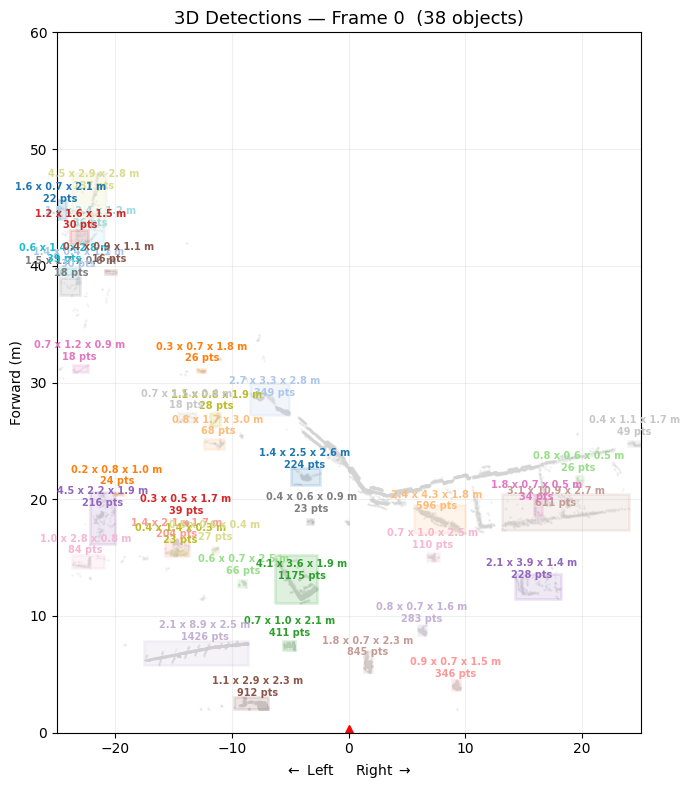

  Object 0: center=(21.9, 3.8, -0.5)  size=1.4 x 2.5 x 2.6 m  (224 pts)
  Object 1: center=(28.1, 6.4, 0.1)  size=2.7 x 3.3 x 2.8 m  (349 pts)
  Object 2: center=(31.0, 12.6, 0.8)  size=0.3 x 0.7 x 1.8 m  (26 pts)
  Object 3: center=(24.8, 11.2, -0.3)  size=0.8 x 1.7 x 3.0 m  (68 pts)
  Object 4: center=(7.5, 5.0, -0.4)  size=0.7 x 1.0 x 2.1 m  (411 pts)
  Object 5: center=(12.8, 9.0, -0.6)  size=0.6 x 0.7 x 2.5 m  (66 pts)
  Object 6: center=(18.0, 13.9, 0.4)  size=0.3 x 0.5 x 1.7 m  (39 pts)
  Object 7: center=(15.9, 14.8, 0.3)  size=1.4 x 2.1 x 1.7 m  (204 pts)
  Object 8: center=(18.7, 21.1, 0.5)  size=4.5 x 2.2 x 1.9 m  (216 pts)
  Object 9: center=(7.1, 12.3, -1.2)  size=2.1 x 8.9 x 2.5 m  (1426 pts)
  Object 10: center=(2.4, 7.8, -0.4)  size=1.1 x 2.9 x 2.3 m  (912 pts)
  Object 11: center=(18.6, -17.7, -0.8)  size=3.1 x 10.9 x 2.7 m  (611 pts)
  Object 12: center=(19.1, -16.1, 1.0)  size=1.8 x 0.7 x 0.5 m  (34 pts)
  Object 13: center=(15.1, -7.2, -0.3)  size=0.7 x 1.0 x 2.5 m 

In [65]:
def cluster_and_extract(points, eps=0.7, min_samples=10,
                        min_pts=15, max_pts=8000,
                        min_h=0.3, max_h=3.5, min_l=0.5, max_l=15.0):
    if len(points) < min_samples:
        return [], np.full(len(points), -1)

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(points)

    detections = []
    for lab in set(labels):
        if lab == -1:
            continue
        cluster = points[labels == lab]
        if len(cluster) < min_pts or len(cluster) > max_pts:
            continue
        bbox_min = cluster.min(axis=0)
        bbox_max = cluster.max(axis=0)
        dims = bbox_max - bbox_min
        h, l = dims[2], max(dims[0], dims[1])
        if h < min_h or h > max_h or l < min_l or l > max_l:
            continue
        detections.append({
            'centroid': cluster.mean(axis=0),
            'bbox_min': bbox_min,
            'bbox_max': bbox_max,
            'dims': dims,
            'n_points': len(cluster),
        })
    return detections, labels


# --- Apply to frame 0 ---
detections_0, labels_0 = cluster_and_extract(non_ground)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(-non_ground[:, 1], non_ground[:, 0], s=0.3, c='lightgray', alpha=0.3)

tab20 = plt.cm.tab20(np.linspace(0, 1, 20))
for i, det in enumerate(detections_0):
    c = tab20[i % 20]
    bmin, bmax = det['bbox_min'], det['bbox_max']
    rect = plt.Rectangle((-bmax[1], bmin[0]),
                          bmax[1] - bmin[1], bmax[0] - bmin[0],
                          linewidth=2, edgecolor=c, facecolor=c, alpha=0.15)
    ax.add_patch(rect)
    cx, cy = -det['centroid'][1], det['centroid'][0]
    ax.text(cx, cy + 0.8,
            f"{det['dims'][0]:.1f} x {det['dims'][1]:.1f} x {det['dims'][2]:.1f} m\n"
            f"{det['n_points']} pts",
            fontsize=7, ha='center', color=c, fontweight='bold')

ax.plot(0, 0, 'r^', markersize=12)
ax.set_xlim(-25, 25); ax.set_ylim(0, 60)
ax.set_aspect('equal')
ax.set_xlabel(r'$\leftarrow$ Left     Right $\rightarrow$')
ax.set_ylabel('Forward (m)')
ax.set_title(f'3D Detections — Frame 0  ({len(detections_0)} objects)', fontsize=13)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

for i, d in enumerate(detections_0):
    print(f"  Object {i}: center=({d['centroid'][0]:.1f}, {d['centroid'][1]:.1f}, "
          f"{d['centroid'][2]:.1f})  size={d['dims'][0]:.1f} x {d['dims'][1]:.1f} x "
          f"{d['dims'][2]:.1f} m  ({d['n_points']} pts)")

## 4. Full Detection Pipeline

Wrap ground removal → clustering → bounding box extraction into one function.

In [ ]:
def detect_objects_3d(velo_points, roi=ROI):
    pts = crop_roi(velo_points[:, :3], roi)
    if len(pts) == 0:
        return []
    ground_mask = remove_ground(pts)
    non_ground = pts[~ground_mask]
    if len(non_ground) < 10:
        return []
    detections, _ = cluster_and_extract(non_ground)
    return detections

# Quick test
for idx in [0, 50, 100, 150]:
    if idx < num_frames:
        dets = detect_objects_3d(data.get_velo(idx))
        print(f"Frame {idx:3d}: {len(dets)} objects detected")

Frame   0: 38 objects detected


### Road Surface Filtering — Connecting N1 to N3

Not all detected objects matter for driving — a cluster on the sidewalk or a building wall should be ignored. We bring in the **SegFormer road segmentation** from N1 to identify the drivable surface.

For each 3D detection, we project the **bottom center** of its bounding box onto the camera image. If that pixel falls on the road mask, the object is kept; otherwise it's filtered out.

This connects the two notebooks: N1's semantic understanding of *what the road is* feeds into N3's tracking of *what's moving on it*.

In [ ]:
import torch
import torch.nn.functional as F_nn
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
from PIL import Image

seg_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024")
seg_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024")
seg_model.eval()
print("SegFormer-B0 loaded (same road segmentation model from N1)")


def get_road_mask(image):
    inputs = seg_processor(images=Image.fromarray(image), return_tensors="pt")
    with torch.no_grad():
        logits = seg_model(**inputs).logits
    upsampled = F_nn.interpolate(logits, size=image.shape[:2],
                                  mode="bilinear", align_corners=False)
    return upsampled.argmax(dim=1).squeeze().cpu().numpy() == 0


def filter_on_road(detections, road_mask, M_proj):
    """Keep detections whose base center projects onto road pixels."""
    on_road = []
    h, w = road_mask.shape
    for det in detections:
        base = np.array([det['centroid'][0], det['centroid'][1],
                         det['bbox_min'][2], 1.0])
        proj = M_proj @ base
        if proj[2] <= 0:
            continue
        u, v = int(round(proj[0] / proj[2])), int(round(proj[1] / proj[2]))
        if 0 <= u < w and 0 <= v < h and road_mask[v, u]:
            on_road.append(det)
    return on_road


# Precompute road masks for all frames
print(f"Computing road masks for {num_frames} frames (this may take a few minutes)...")
road_masks = []
for i in range(num_frames):
    if i % 20 == 0:
        print(f"  Frame {i}/{num_frames}")
    road_masks.append(get_road_mask(np.array(data.get_cam2(i))))
print(f"Done — {num_frames} road masks cached")

# --- Compare: all detections vs road-only on frame 0 ---
all_dets_0 = detect_objects_3d(data.get_velo(0))
road_dets_0 = filter_on_road(all_dets_0, road_masks[0], M_proj)

fig, (ax_cam, ax_bev) = plt.subplots(1, 2, figsize=(16, 6),
                                       gridspec_kw={'width_ratios': [1.2, 1]})
img_0 = np.array(data.get_cam2(0))
overlay = img_0.copy()
overlay[road_masks[0]] = (0.5 * overlay[road_masks[0]] +
                           0.5 * np.array([0, 180, 0])).astype(np.uint8)
ax_cam.imshow(overlay)
ax_cam.set_title('Road Segmentation (SegFormer from N1)', fontsize=13)
ax_cam.axis('off')

tab20 = plt.cm.tab20(np.linspace(0, 1, 20))
for det in all_dets_0:
    bmin, bmax = det['bbox_min'], det['bbox_max']
    rect = plt.Rectangle((-bmax[1], bmin[0]), bmax[1]-bmin[1], bmax[0]-bmin[0],
                          linewidth=1.5, edgecolor='gray', facecolor='none', linestyle='--')
    ax_bev.add_patch(rect)

for i, det in enumerate(road_dets_0):
    c = tab20[i % 20]
    bmin, bmax = det['bbox_min'], det['bbox_max']
    rect = plt.Rectangle((-bmax[1], bmin[0]), bmax[1]-bmin[1], bmax[0]-bmin[0],
                          linewidth=2, edgecolor=c, facecolor=c, alpha=0.15)
    ax_bev.add_patch(rect)
    ax_bev.text(-det['centroid'][1], det['centroid'][0] + 1,
                f"{det['dims'][0]:.1f}×{det['dims'][1]:.1f}m",
                color=c, fontsize=8, ha='center', fontweight='bold')

ax_bev.plot(0, 0, 'r^', markersize=12)
ax_bev.set_xlim(-25, 25); ax_bev.set_ylim(0, 60)
ax_bev.set_aspect('equal')
ax_bev.set_title(f'Detections: {len(all_dets_0)} total → {len(road_dets_0)} on road',
                 fontsize=13)
ax_bev.set_xlabel(r'$\leftarrow$ Left     Right $\rightarrow$')
ax_bev.set_ylabel('Forward (m)')
ax_bev.grid(True, alpha=0.2)
ax_bev.legend(handles=[
    mpatches.Patch(edgecolor='gray', facecolor='none', linestyle='--',
                   label='Off-road (filtered)'),
    mpatches.Patch(edgecolor='tab:blue', facecolor='tab:blue', alpha=0.3,
                   label='On-road (kept)'),
], fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()
print(f"Road filtering: {len(all_dets_0)} detections → {len(road_dets_0)} on-road objects")

In [ ]:
# Estimate ground plane height from LiDAR (same approach as N1)
ground_candidates = velo_0[(velo_0[:, 0] > 3) & (velo_0[:, 0] < 25) &
                           (np.abs(velo_0[:, 1]) < 6)]
z_ground = np.percentile(ground_candidates[:, 2], 5)

def backproject_to_ground(pixels_uv, M, z_ground):
    """Back-project 2D pixels to 3D ground plane (from N1)."""
    u = pixels_uv[:, 0].astype(np.float64)
    v = pixels_uv[:, 1].astype(np.float64)
    a = M[0, 2] * z_ground + M[0, 3]
    b = M[1, 2] * z_ground + M[1, 3]
    c = M[2, 2] * z_ground + M[2, 3]
    A00 = M[0, 0] - u * M[2, 0]
    A01 = M[0, 1] - u * M[2, 1]
    A10 = M[1, 0] - v * M[2, 0]
    A11 = M[1, 1] - v * M[2, 1]
    rhs0 = u * c - a
    rhs1 = v * c - b
    det = A00 * A11 - A01 * A10
    det[det == 0] = np.nan
    X = (rhs0 * A11 - rhs1 * A01) / det
    Y = (A00 * rhs1 - A10 * rhs0) / det
    return np.stack([X, Y, np.full_like(X, z_ground)], axis=1)

# Back-project road masks to BEV with camera colors for every frame
print(f"Back-projecting road surfaces for {num_frames} frames...")
road_bev = []
road_bev_colors = []
for i in range(num_frames):
    img_i = np.array(data.get_cam2(i))
    rv, ru = np.where(road_masks[i])
    if len(rv) > 0:
        step = max(1, len(rv) // 8000)
        px = np.stack([ru[::step], rv[::step]], axis=1)
        colors = img_i[rv[::step], ru[::step]] / 255.0
        pts = backproject_to_ground(px, M_proj, z_ground)
        valid = (np.isfinite(pts[:, 0]) & (pts[:, 0] > 0) & (pts[:, 0] < 60) &
                 (np.abs(pts[:, 1]) < 25))
        road_bev.append(pts[valid])
        road_bev_colors.append(colors[valid])
    else:
        road_bev.append(np.empty((0, 3)))
        road_bev_colors.append(np.empty((0, 3)))
    if i % 20 == 0:
        print(f"  Frame {i}/{num_frames}")
print(f"Done — road BEV with camera colors cached for {num_frames} frames")

In [ ]:
# Ego-motion compensation: transform all frames to frame 0's coordinate system
# using GPS/IMU poses so stationary objects don't appear to move

T_velo_imu = np.eye(4)
T_velo_imu[:3, :3] = np.array([
    9.999976e-01, 7.553071e-04, -2.035826e-03,
    -7.854027e-04, 9.998898e-01, -1.482298e-02,
    2.024406e-03, 1.482454e-02, 9.998881e-01
]).reshape(3, 3)
T_velo_imu[:3, 3] = np.array([-8.086759e-01, 3.195559e-01, -7.997231e-01])

T_imu_velo = np.linalg.inv(T_velo_imu)
oxts_all = list(data.oxts)
T_w0_inv = np.linalg.inv(oxts_all[0].T_w_imu)

ego_poses = []
for i in range(num_frames):
    T_wi = oxts_all[i].T_w_imu
    ego_poses.append(T_velo_imu @ T_w0_inv @ T_wi @ T_imu_velo)

ego_positions = np.array([T[:3, 3] for T in ego_poses])
ego_headings = np.array([np.arctan2(T[1, 0], T[0, 0]) for T in ego_poses])

total_dist = np.sum(np.linalg.norm(np.diff(ego_positions, axis=0), axis=1))
print(f"Ego poses computed for {num_frames} frames")
print(f"Total distance: {total_dist:.1f} m  |  "
      f"Heading: [{np.degrees(ego_headings.min()):.1f}°, {np.degrees(ego_headings.max()):.1f}°]")

## 5. 3D Multi-Object Tracking with Kalman Filter

We track detected objects across frames using the same Kalman filter structure from N2, extended to 3D.

**State vector**: $\hat{x} = [x,\; y,\; z,\; v_x,\; v_y,\; v_z]^\top$ — position and velocity in the Velodyne frame

**State transition** (constant velocity):

$$F = \begin{bmatrix} I_3 & \Delta t \cdot I_3 \\ 0_3 & I_3 \end{bmatrix}$$

**Measurement**: observe position only — $z = [x,\; y,\; z]$, $\;\; H = \begin{bmatrix} I_3 & 0_3 \end{bmatrix}$

**Data association**: Hungarian algorithm on 3D Euclidean distance between predicted track positions and new detections — same idea as IoU matching in N4, but in metric space.

**Ego-motion compensation**: before feeding detections to the tracker, we transform each frame's 3D coordinates into a fixed world frame (frame 0) using GPS/IMU poses. This prevents the car's own rotation and translation from contaminating tracked velocities — stationary objects stay still, and prediction arrows reflect true object motion.

In [ ]:
class Track3D:
    _next_id = 0

    def __init__(self, detection, dt):
        self.id = Track3D._next_id
        Track3D._next_id += 1

        cx, cy, cz = detection['centroid']
        self.x = np.array([cx, cy, cz, 0.0, 0.0, 0.0])
        self.P = np.diag([1.0, 1.0, 1.0, 10.0, 10.0, 10.0])

        self.F = np.eye(6)
        self.F[0, 3] = dt
        self.F[1, 4] = dt
        self.F[2, 5] = dt

        self.H = np.zeros((3, 6))
        self.H[0, 0] = self.H[1, 1] = self.H[2, 2] = 1.0

        q = 2.0
        G = np.zeros((6, 3))
        G[0, 0] = G[1, 1] = G[2, 2] = dt**2 / 2
        G[3, 0] = G[4, 1] = G[5, 2] = dt
        self.Q = q**2 * (G @ G.T)

        self.R = np.diag([0.3, 0.3, 0.2]) ** 2

        self.hits = 1
        self.misses = 0
        self.age = 0
        self.history = [self.x[:3].copy()]
        self.last_det = detection

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        self.age += 1

    def update(self, detection):
        z = detection['centroid']
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(6) - K @ self.H) @ self.P
        self.hits += 1
        self.misses = 0
        self.history.append(self.x[:3].copy())
        self.last_det = detection

    def predict_future(self, n_steps=5):
        positions = []
        x_tmp = self.x.copy()
        for _ in range(n_steps):
            x_tmp = self.F @ x_tmp
            positions.append(x_tmp[:3].copy())
        return positions

print("Track3D class defined — state: [x, y, z, vx, vy, vz]")

## 6. Run Tracker on Full Sequence

Process all frames: detect 3D objects → **filter to road-only** using the precomputed SegFormer masks → **transform to world frame** using GPS/IMU poses → update the Kalman tracker → record state for visualization.

In [ ]:
Track3D._next_id = 0
tracker = LiDARTracker(dt=dt)
frame_results = []

print(f"Processing {num_frames} frames (road filtering + ego-motion compensation)...")
for i in range(num_frames):
    if i % 20 == 0:
        print(f"  Frame {i:3d}/{num_frames}  |  {len(tracker.confirmed())} confirmed tracks")

    dets = detect_objects_3d(data.get_velo(i))
    dets = filter_on_road(dets, road_masks[i], M_proj)

    # Transform detection centroids to world frame (frame 0)
    T_i = ego_poses[i]
    T_i_inv = np.linalg.inv(T_i)
    for det in dets:
        c_h = np.append(det['centroid'], 1.0)
        det['centroid'] = (T_i @ c_h)[:3]

    tracker.step(dets)

    frame_results.append({
        'detections': dets,
        'tracks': [{
            'id': t.id,
            'pos': t.x[:3].copy(),
            'vel': t.x[3:6].copy(),
            'history': [h.copy() for h in t.history[-30:]],
            'predictions': t.predict_future(5),
            'bbox_min': t.last_det['bbox_min'].copy(),
            'bbox_max': t.last_det['bbox_max'].copy(),
        } for t in tracker.confirmed()],
        'ego_pos': ego_positions[i],
        'ego_heading': ego_headings[i],
        'T_ego_to_world': T_i,
        'T_world_to_ego': T_i_inv,
    })

total_ids = max((t.id for t in tracker.tracks), default=-1) + 1
print(f"\nDone! Unique track IDs created: {total_ids}")
print(f"Confirmed tracks at last frame: {len(tracker.confirmed())}")

In [ ]:
track_colors = plt.cm.tab20(np.linspace(0, 1, 20))

def plot_bev_frame(ax, fr, title="", road_pts=None, road_clr=None):
    ego = fr.get('ego_pos', np.zeros(3))
    heading = fr.get('ego_heading', 0.0)

    cx, cy = -ego[1], ego[0]
    ax.set_xlim(cx - 20, cx + 20)
    ax.set_ylim(cy - 10, cy + 45)
    ax.set_aspect('equal')
    ax.set_facecolor('#e8e8e8')
    ax.grid(True, alpha=0.15)

    # Road surface (transform ego-frame points to world frame)
    if road_pts is not None and len(road_pts) > 0:
        T_ew = fr.get('T_ego_to_world')
        if T_ew is not None:
            rp_h = np.hstack([road_pts, np.ones((len(road_pts), 1))])
            rp_w = (T_ew @ rp_h.T).T[:, :3]
        else:
            rp_w = road_pts
        c = road_clr if road_clr is not None else '#a5d6a7'
        ax.scatter(-rp_w[:, 1], rp_w[:, 0], s=1.5, c=c,
                   alpha=0.6, zorder=1, edgecolors='none')

    # Ego vehicle — rotated triangle showing heading
    s = 1.5
    tri = np.array([[s, 0], [-s, -s * 0.7], [-s, s * 0.7]])
    R = np.array([[np.cos(heading), -np.sin(heading)],
                  [np.sin(heading),  np.cos(heading)]])
    tri_r = (R @ tri.T).T
    tri_bev = np.column_stack([-tri_r[:, 1] + cx, tri_r[:, 0] + cy])
    ego_patch = mpatches.Polygon(tri_bev, closed=True, facecolor='red',
                                  edgecolor='darkred', linewidth=1.5, zorder=10)
    ax.add_patch(ego_patch)
    ax.set_title(title, fontsize=11)

    for tr in fr['tracks']:
        c = track_colors[tr['id'] % 20]
        dims = tr['bbox_max'] - tr['bbox_min']
        half = dims / 2
        bmin_w = tr['pos'] - half
        bmax_w = tr['pos'] + half
        rect = plt.Rectangle((-bmax_w[1], bmin_w[0]),
                              bmax_w[1] - bmin_w[1], bmax_w[0] - bmin_w[0],
                              linewidth=2, edgecolor=c, facecolor=c, alpha=0.25,
                              zorder=5)
        ax.add_patch(rect)

        hist = np.array(tr['history'])
        if len(hist) > 1:
            ax.plot(-hist[:, 1], hist[:, 0], color=c, linewidth=2.5,
                    alpha=0.8, zorder=6)

        if tr['predictions']:
            last_p = tr['predictions'][-1]
            ax.annotate('', xy=(-last_p[1], last_p[0]),
                        xytext=(-tr['pos'][1], tr['pos'][0]),
                        arrowprops=dict(arrowstyle='->', color=c, lw=2.5,
                                        mutation_scale=15),
                        zorder=7)

        ax.text(-tr['pos'][1], tr['pos'][0] + 1.2, f"{tr['id']}",
                color=c, fontsize=7, ha='center', fontweight='bold',
                zorder=8)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sample_frames = [0, 40, 80, 120]
for ax, fi in zip(axes.flat, sample_frames):
    fi = min(fi, num_frames - 1)
    plot_bev_frame(ax, frame_results[fi],
                   f"Frame {fi} — {len(frame_results[fi]['tracks'])} tracks",
                   road_pts=road_bev[fi], road_clr=road_bev_colors[fi])
    trail = ego_positions[:fi + 1]
    ax.plot(-trail[:, 1], trail[:, 0], 'r-', linewidth=1.5, alpha=0.3, zorder=9)
    ax.set_xlabel(r'$\leftarrow$ Left     Right $\rightarrow$')
    ax.set_ylabel('Forward (m)')

plt.tight_layout()
plt.show()

In [ ]:
track_colors = plt.cm.tab20(np.linspace(0, 1, 20))

def plot_bev_frame(ax, fr, title="", road_pts=None, road_clr=None):
    ax.set_xlim(-20, 20)
    ax.set_ylim(0, 55)
    ax.set_aspect('equal')
    ax.set_facecolor('#e8e8e8')
    ax.grid(True, alpha=0.15)

    if road_pts is not None and len(road_pts) > 0:
        c = road_clr if road_clr is not None else '#a5d6a7'
        ax.scatter(-road_pts[:, 1], road_pts[:, 0], s=1.5, c=c,
                   alpha=0.6, zorder=1, edgecolors='none')

    ax.plot(0, 0, 'r^', markersize=8, zorder=10)
    ax.set_title(title, fontsize=11)

    for tr in fr['tracks']:
        c = track_colors[tr['id'] % 20]
        bmin, bmax = tr['bbox_min'], tr['bbox_max']
        rect = plt.Rectangle((-bmax[1], bmin[0]),
                              bmax[1] - bmin[1], bmax[0] - bmin[0],
                              linewidth=2, edgecolor=c, facecolor=c, alpha=0.25,
                              zorder=5)
        ax.add_patch(rect)

        hist = np.array(tr['history'])
        if len(hist) > 1:
            ax.plot(-hist[:, 1], hist[:, 0], color=c, linewidth=2.5,
                    alpha=0.8, zorder=6)

        if tr['predictions']:
            last_p = tr['predictions'][-1]
            ax.annotate('', xy=(-last_p[1], last_p[0]),
                        xytext=(-tr['pos'][1], tr['pos'][0]),
                        arrowprops=dict(arrowstyle='->', color=c, lw=2.5,
                                        mutation_scale=15),
                        zorder=7)

        ax.text(-tr['pos'][1], tr['pos'][0] + 1.2, f"{tr['id']}",
                color=c, fontsize=7, ha='center', fontweight='bold',
                zorder=8)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sample_frames = [0, 40, 80, 120]
for ax, fi in zip(axes.flat, sample_frames):
    fi = min(fi, num_frames - 1)
    plot_bev_frame(ax, frame_results[fi],
                   f"Frame {fi} — {len(frame_results[fi]['tracks'])} tracks",
                   road_pts=road_bev[fi], road_clr=road_bev_colors[fi])
    ax.set_xlabel(r'$\leftarrow$ Left     Right $\rightarrow$')
    ax.set_ylabel('Forward (m)')

plt.tight_layout()
plt.show()

## 8. Tracking Video — BEV + Camera Projection

Render a side-by-side video:
- **Left**: camera image with projected 3D bounding boxes, track IDs, and **prediction arrows** showing where each object is heading
- **Right**: bird's-eye view with trajectory history (solid) and prediction arrows

In [ ]:
BOX_EDGES = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]

def get_box_corners(bmin, bmax):
    x0, y0, z0 = bmin
    x1, y1, z1 = bmax
    return np.array([[x0,y0,z0],[x1,y0,z0],[x1,y1,z0],[x0,y1,z0],
                     [x0,y0,z1],[x1,y0,z1],[x1,y1,z1],[x0,y1,z1]])

os.makedirs('videos', exist_ok=True)
writer = imageio.get_writer('videos/lidar_tracking.mp4', fps=10, quality=7)

print(f"Rendering {num_frames} frames to video...")
for fi in range(num_frames):
    if fi % 20 == 0:
        print(f"  Rendering frame {fi}/{num_frames}")

    fig, (ax_cam, ax_bev) = plt.subplots(
        1, 2, figsize=(16, 5.5), dpi=100,
        gridspec_kw={'width_ratios': [1.2, 1]})

    # --- Camera panel ---
    img = np.array(data.get_cam2(fi))
    ax_cam.imshow(img)
    ax_cam.set_title(f'Frame {fi} / {num_frames - 1}', fontsize=11)
    ax_cam.axis('off')

    fr = frame_results[fi]
    h_img, w_img = img.shape[:2]
    T_w2e = fr['T_world_to_ego']

    for tr in fr['tracks']:
        c = track_colors[tr['id'] % 20]
        corners = get_box_corners(tr['bbox_min'], tr['bbox_max'])
        hom = np.hstack([corners, np.ones((8, 1))])
        proj = (M_proj @ hom.T).T
        depth = proj[:, 2]
        valid = depth > 0.5
        pts2d = np.zeros((8, 2))
        if valid.any():
            pts2d[valid] = proj[valid, :2] / proj[valid, 2:3]

        in_img = (valid &
                  (pts2d[:, 0] >= 0) & (pts2d[:, 0] < w_img) &
                  (pts2d[:, 1] >= 0) & (pts2d[:, 1] < h_img))

        for ei, ej in BOX_EDGES:
            if in_img[ei] and in_img[ej]:
                ax_cam.plot([pts2d[ei, 0], pts2d[ej, 0]],
                            [pts2d[ei, 1], pts2d[ej, 1]],
                            color=c, linewidth=1.5)

        if in_img.any():
            cx2d = pts2d[in_img, 0].mean()
            cy2d = pts2d[in_img, 1].min() - 6
            ax_cam.text(cx2d, max(cy2d, 5), f'ID {tr["id"]}',
                        color=c, fontsize=8, fontweight='bold', ha='center',
                        bbox=dict(boxstyle='round,pad=0.15',
                                  facecolor='black', alpha=0.5))

        # Prediction arrow: world frame → ego frame → camera projection
        if tr['predictions']:
            pred_5 = tr['predictions'][-1]
            cur_ego = (T_w2e @ np.array([*tr['pos'], 1.0]))[:3]
            pred_ego = (T_w2e @ np.array([*pred_5, 1.0]))[:3]
            cp = M_proj @ np.array([*cur_ego, 1.0])
            pp = M_proj @ np.array([*pred_ego, 1.0])
            if cp[2] > 0.5 and pp[2] > 0.5:
                cu, cv = cp[0]/cp[2], cp[1]/cp[2]
                pu, pv = pp[0]/pp[2], pp[1]/pp[2]
                if (0 <= cu < w_img and 0 <= cv < h_img and
                    0 <= pu < w_img and 0 <= pv < h_img):
                    ax_cam.annotate('', xy=(pu, pv), xytext=(cu, cv),
                                   arrowprops=dict(arrowstyle='->', color=c,
                                                   lw=2.5, mutation_scale=15))

    # --- BEV panel (world frame, centered on ego) ---
    plot_bev_frame(ax_bev, fr, f'{len(fr["tracks"])} tracked objects',
                   road_pts=road_bev[fi], road_clr=road_bev_colors[fi])
    trail = ego_positions[:fi + 1]
    ax_bev.plot(-trail[:, 1], trail[:, 0], 'r-', linewidth=1.5, alpha=0.3, zorder=9)
    ax_bev.set_xlabel(r'$\leftarrow$ Left     Right $\rightarrow$', fontsize=9)
    ax_bev.set_ylabel('Forward (m)', fontsize=9)

    plt.tight_layout()
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    frame_img = np.frombuffer(fig.canvas.buffer_rgba(),
                              dtype=np.uint8).reshape(h, w, 4)[:, :, :3]
    writer.append_data(frame_img)
    plt.close(fig)

writer.close()
print(f"\nSaved: videos/lidar_tracking.mp4  ({num_frames} frames @ 10 fps)")

## Summary

This notebook built a complete 3D LiDAR detection and tracking pipeline from scratch:

1. **Ground removal** — surface normal estimation identifies horizontal surfaces by finding points whose local neighborhood is approximately flat ($|\mathbf{n}_z| > 0.85$)
2. **Euclidean clustering** — DBSCAN groups nearby non-ground points into object candidates
3. **3D bounding boxes** — axis-aligned boxes from cluster extents, filtered by vehicle dimensions
4. **Road filtering** — SegFormer road segmentation (from N1) projects each detection's base onto the camera image and keeps only objects on the drivable surface
5. **Ego-motion compensation** — GPS/IMU poses transform all detections into a fixed world frame, so stationary objects stay still and tracked velocities reflect true object motion
6. **Kalman filter tracking** — constant-velocity model in 3D $[x,y,z,v_x,v_y,v_z]$ with Hungarian assignment for data association
7. **Future prediction** — extrapolating each track's estimated velocity to forecast where it will be 5 timesteps (~0.5 s) in the future, visualized as arrows on both camera and BEV views

### Key Takeaways

- LiDAR gives **direct 3D measurements** — no monocular depth estimation needed
- Normal filtering is a **geometric** approach to ground removal that generalizes to uneven terrain
- The same **Kalman filter from N2** extends naturally to 3D: predict in $[x,y,z,v_x,v_y,v_z]$, observe $[x,y,z]$
- **Connecting N1 → N3**: semantic road segmentation from camera images filters LiDAR detections to only road-relevant objects — a concrete example of camera–LiDAR fusion
- **Ego-motion compensation** using GPS/IMU ensures prediction arrows show true object trajectories, not artifacts of the car's own motion — the BEV shows a stabilized world view where the ego vehicle moves through the scene

### What's Next

- **N4** — Multi-Object Tracking on camera images with YOLO detections and 2D bounding boxes
- Fusing LiDAR 3D tracks with camera 2D tracks for robust multi-modal perception